In [1]:
import dotenv

dotenv.load_dotenv('../vars.env')

True

In [3]:
from databricks_langchain import ChatDatabricks
llm = ChatDatabricks(model='agents-demo-gpt4o', temperature=0)

In [13]:
import wikipedia
titles = wikipedia.search('why ww2 started?', results=3)
print(titles)
wiki = {}
for title in titles:
    wiki[title] = wikipedia.summary(title)

' '.join(wiki.values())

['List of World War II infantry weapons', 'Surrender of Japan', 'Causes of World War II']


'This is a list of World War II infantry weapons.\n\n The surrender of the Empire of Japan in World War II was announced by Emperor Hirohito on 15 August and formally signed on 2 September 1945, ending the war. By the end of July 1945, the Imperial Japanese Navy (IJN) was incapable of conducting major operations and an Allied invasion of Japan was imminent. Together with the United Kingdom and China, the United States called for the unconditional surrender of Japan in the Potsdam Declaration on 26 July 1945—the alternative being "prompt and utter destruction". While publicly stating their intent to fight on to the bitter end, Japan\'s leaders (the Supreme Council for the Direction of the War, also known as the "Big Six") were privately making entreaties to the publicly neutral Soviet Union to mediate peace on terms more favorable to the Japanese. While maintaining a sufficient level of diplomatic engagement with the Japanese to give them the impression they might be willing to mediate,

In [33]:
from tavily import TavilyClient

# Initialize Tavily client with your API key
tavily_client = TavilyClient(api_key="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")

# Search and limit results to 3
response = tavily_client.search('why ww2 started?', max_results=3)

' '.join(result['content'] for result in response['results'])


'World War II began due to multiple factors that Adolf Hitler executed. His political goals included expanding German territory and propagating Granted, Germany’s invasion of Poland in 1939 triggered declarations of war from France and the United Kingdom, formally starting World War II. In 1919, representatives from more than two dozen countries gathered in France to draft peace treaties that would set the terms for the end of World War I. The League included most of the victors of World War I, and eventually expanded to include Germany and the other defeated nations. In reality, complex dynamics—including the rise of radical nationalism, U.S. isolationism, the failure to maintain a global balance of power, and misplaced optimism that World War I had been the war to end all wars—propelled countries around the world into combat. The immediate precipitating event was the invasion of Poland by Nazi Germany on September 1, 1939, and the subsequent declarations of war on Germany made by Bri

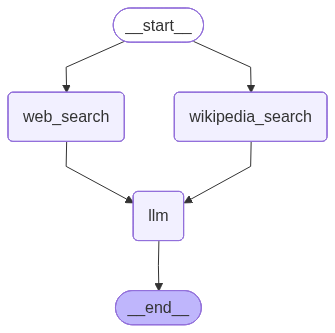

In [34]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_core.messages import SystemMessage, HumanMessage
import wikipedia

class State(MessagesState):
    wiki: str
    web: str

def wikipedia_search_node(state: State) -> State:
    titles = wikipedia.search(state['messages'][-1].content, results=3)
    wiki = {}
    for title in titles:
        wiki[title] = wikipedia.summary(title)

    return {'wiki': ' '.join(wiki.values())}

def web_search_node(state: State) -> State:
    tavily_client = TavilyClient(api_key="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")

    # Search and limit results to 3
    response = tavily_client.search(state['messages'][-1].content, max_results=3)

    return {'web': (' '.join(result['content'] for result in response['results']))}

def llm_node(state: State) -> State:
    system_message = 'You are a helpful assistant tasked to answer the following question:\n{question}\n\n based on the following information:\n{context}'
    context = state['wiki'] + ' ' + state['web']
    system_prompt = SystemMessage(content=system_message.format(question=state['messages'][-1].content, context=context))

    return {'messages': [llm.invoke([system_prompt])]}


graph = StateGraph(State)

graph.add_node('wikipedia_search', wikipedia_search_node)
graph.add_node('web_search', web_search_node)
graph.add_node('llm', llm_node)

graph.add_edge(START, 'wikipedia_search')
graph.add_edge(START, 'web_search')
graph.add_edge('web_search', 'llm')
graph.add_edge('wikipedia_search', 'llm')
graph.add_edge('llm', END)

app = graph.compile()
app

In [35]:
query = 'why ww2 started?'
messages = app.invoke({'messages': [HumanMessage(query)]})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

why ww2 started?
================================== Ai Message ==================================

World War II started due to a combination of long-term and immediate factors, rooted in political, economic, and ideological tensions that had been building for decades. The immediate trigger was **Germany's invasion of Poland on September 1, 1939**, which led Britain and France to declare war on Germany. However, the deeper causes of the conflict were far more complex:

### 1. **Treaty of Versailles and Resentment in Germany**
   - The harsh terms of the Treaty of Versailles (1919), which ended World War I, left Germany economically devastated and politically humiliated. Reparations, territorial losses, and military restrictions fueled resentment and a desire for revenge among Germans.
   - Adolf Hitler capitalized on this anger, promoting radical nationalism and promising to restore Germany's power and pre

In [37]:
from typing import TypedDict, Annotated
import operator
class State(TypedDict):
    question: str
    answer: str
    context: Annotated[list, operator.add]

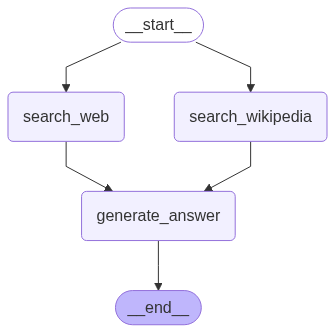

In [44]:
from langchain_core.messages import HumanMessage, SystemMessage

from langchain_community.document_loaders import WikipediaLoader
from langchain_community.tools import TavilySearchResults

def search_web(state):
    
    """ Retrieve docs from web search """

    # Search
    tavily_search = TavilySearchResults(max_results=3, tavily_api_key="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")
    search_docs = tavily_search.invoke(state['question'])

     # Format
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document href="{doc["url"]}">\n{doc["content"]}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]} 

def search_wikipedia(state):
    
    """ Retrieve docs from wikipedia """

    # Search
    search_docs = WikipediaLoader(query=state['question'], 
                                  load_max_docs=2).load()

     # Format
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document source="{doc.metadata["source"]}" page="{doc.metadata.get("page", "")}">\n{doc.page_content}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]} 

def generate_answer(state):
    
    """ Node to answer a question """

    # Get state
    context = state["context"]
    question = state["question"]

    # Template
    answer_template = """Answer the question {question} using this context: {context}\n\n--\n\nProvide the answer in Markdown format, and whenever you use a document from the context, use the source to reference to it in-line in clickable bracket format like [1], [2], etc., and provide the reference at the end."""
    answer_instructions = answer_template.format(question=question, 
                                                       context=context)    
    
    # Answer
    answer = llm.invoke([SystemMessage(content=answer_instructions)]+[HumanMessage(content=f"Answer the question.")])
      
    # Append it to state
    return {"answer": answer}

# Add nodes
builder = StateGraph(State)

# Initialize each node with node_secret 
builder.add_node("search_web",search_web)
builder.add_node("search_wikipedia", search_wikipedia)
builder.add_node("generate_answer", generate_answer)

# Flow
builder.add_edge(START, "search_wikipedia")
builder.add_edge(START, "search_web")
builder.add_edge("search_wikipedia", "generate_answer")
builder.add_edge("search_web", "generate_answer")
builder.add_edge("generate_answer", END)
graph = builder.compile()

graph

In [45]:
result = graph.invoke({"question": "How were Nvidia's Q2 2024 earnings"})
result['answer'].content

"Nvidia's Q2 2024 earnings were exceptional, marking a record quarter with revenue of $30 billion, which was up 15% sequentially and 122% year-over-year. The Data Center segment contributed significantly, achieving a record revenue of $26.3 billion, up 16% sequentially and 154% year-over-year, driven by strong demand for NVIDIA Hopper GPU computing and networking platforms. Additionally, Nvidia returned $15.4 billion to shareholders during the first half of fiscal 2025 through share repurchases and cash dividends, and its Board of Directors approved an additional $50 billion in share repurchase authorization [1][2][3].\n\n---\n\n### References:\n1. [YouTube Earnings Report](https://www.youtube.com/watch?v=MvKvcpZQWag)\n2. [HPC Wire Financial Results](https://www.hpcwire.com/off-the-wire/nvidia-announces-financial-results-for-2nd-quarter-fiscal-2025/)\n3. [Nvidia Newsroom](https://nvidianews.nvidia.com/news/nvidia-announces-financial-results-for-second-quarter-fiscal-2025)"

Nvidia's Q2 2024 earnings were exceptional, marking a record quarter with revenue of $30 billion, which was up 15% sequentially and 122% year-over-year. The Data Center segment contributed significantly, achieving a record revenue of $26.3 billion, up 16% sequentially and 154% year-over-year, driven by strong demand for Nvidia's Hopper GPU computing and networking platforms. Additionally, Nvidia returned $15.4 billion to shareholders during the first half of fiscal 2025 through share repurchases and cash dividends, and its Board of Directors approved an additional $50 billion in share repurchase authorization [1][2][3].\n\n---\n\n### References:\n1. [YouTube Earnings Summary](https://www.youtube.com/watch?v=MvKvcpZQWag)\n2. [HPC Wire Financial Results](https://www.hpcwire.com/off-the-wire/nvidia-announces-financial-results-for-2nd-quarter-fiscal-2025/)\n3. [Nvidia Newsroom](https://nvidianews.nvidia.com/news/nvidia-announces-financial-results-for-second-quarter-fiscal-2025)"

In [46]:
print(result['answer'].content)

Nvidia's Q2 2024 earnings were exceptional, marking a record quarter with revenue of $30 billion, which was up 15% sequentially and 122% year-over-year. The Data Center segment contributed significantly, achieving a record revenue of $26.3 billion, up 16% sequentially and 154% year-over-year, driven by strong demand for NVIDIA Hopper GPU computing and networking platforms. Additionally, Nvidia returned $15.4 billion to shareholders during the first half of fiscal 2025 through share repurchases and cash dividends, and its Board of Directors approved an additional $50 billion in share repurchase authorization [1][2][3].

---

### References:
1. [YouTube Earnings Report](https://www.youtube.com/watch?v=MvKvcpZQWag)
2. [HPC Wire Financial Results](https://www.hpcwire.com/off-the-wire/nvidia-announces-financial-results-for-2nd-quarter-fiscal-2025/)
3. [Nvidia Newsroom](https://nvidianews.nvidia.com/news/nvidia-announces-financial-results-for-second-quarter-fiscal-2025)
